In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [5]:
X = []
Y = []

img_size = 128

base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

In [6]:
for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (img_size, img_size))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize
        img = img.astype('float32') / 255.0

        # Flatten
        img = img.flatten()

        X.append(img)

        Y.append(label)
X = np.array(X)

Y = np.array(Y)

print("Original Shape :", X.shape)

Original Shape : (2870, 49152)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    Y,

    test_size = 0.2,

    stratify = Y,

    random_state = 42
)


In [8]:
pca = PCA(n_components=200)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

print("After PCA Shape :", X_train_pca.shape)

After PCA Shape : (2296, 200)


In [9]:
xgb_model = XGBClassifier(

    n_estimators = 100,

    max_depth = 6,

    learning_rate = 0.1,

    objective = 'multi:softmax',

    num_class = 4,

    eval_metric = 'mlogloss',

    random_state = 42
)


In [10]:
print("\nTraining PCA + XGBoost Model...\n")

xgb_model.fit(X_train_pca, y_train)
y_pred = xgb_model.predict(X_test_pca)


Training PCA + XGBoost Model...



In [11]:
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)

sensitivity_list = []

specificity_list = []

for i in range(len(classes)):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    sensitivity_list.append(sensitivity)

    specificity_list.append(specificity)

avg_sensitivity = np.mean(sensitivity_list)

avg_specificity = np.mean(specificity_list)

In [12]:
print("\n===================================================")
print("     BRAIN TUMOR PCA + XGBOOST RESULTS")
print("===================================================\n")

print(f"Accuracy      : {accuracy*100:.2f}%")

print(f"F1-Score      : {f1:.4f}")

print(f"Sensitivity   : {avg_sensitivity:.4f}")

print(f"Specificity   : {avg_specificity:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=list(classes.keys())
))

print("\nConfusion Matrix:\n")

print(cm)


     BRAIN TUMOR PCA + XGBOOST RESULTS

Accuracy      : 81.01%
F1-Score      : 0.8076
Sensitivity   : 0.7867
Specificity   : 0.9336

Classification Report:

                  precision    recall  f1-score   support

        no_tumor       0.96      0.63      0.76        79
 pituitary_tumor       0.85      0.96      0.90       166
    glioma_tumor       0.80      0.79      0.79       165
meningioma_tumor       0.74      0.77      0.75       164

        accuracy                           0.81       574
       macro avg       0.84      0.79      0.80       574
    weighted avg       0.82      0.81      0.81       574


Confusion Matrix:

[[ 50   6   9  14]
 [  1 159   1   5]
 [  0   9 130  26]
 [  1  14  23 126]]


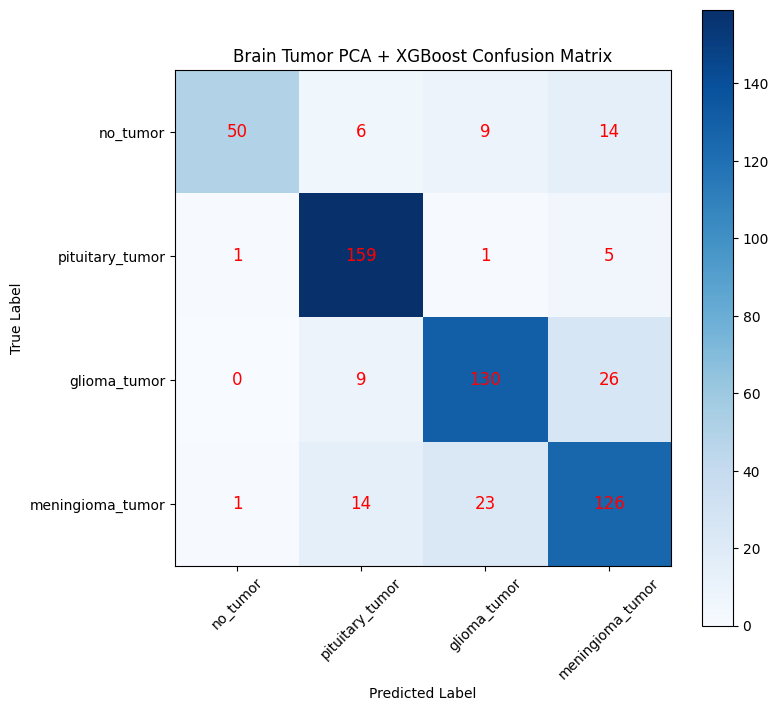

In [13]:
import matplotlib.pyplot as plt

class_names = list(classes.keys())

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap='Blues')

plt.title("Brain Tumor PCA + XGBoost Confusion Matrix")

plt.xticks(range(len(class_names)), class_names, rotation=45)

plt.yticks(range(len(class_names)), class_names)

# Display values inside matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='red',
            fontsize=12
        )

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.colorbar()

plt.show()